In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Sphere, Cylinder, SandiB, SandiW, BallStickSharedDiffusivity, Ball3StickSharedDiffusivity, MultiCompartment
from dmri.simulators.acquisition_scheme import acquisition_scheme
from dmri.simulators import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


# Diffusion MRI Simulators

Based on bvals and bvecs, we can create an acquisition scheme.

In [3]:
bvals = jnp.linspace(0, 4000, 100)
bvecs = jax.random.normal(jax.random.key(0), (100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

acq = acquisition_scheme(bvals, bvecs)

In [4]:
class Test(MultiCompartment):
    model_types=[Ball, Stick, Zeppelin]
    noise_types = []

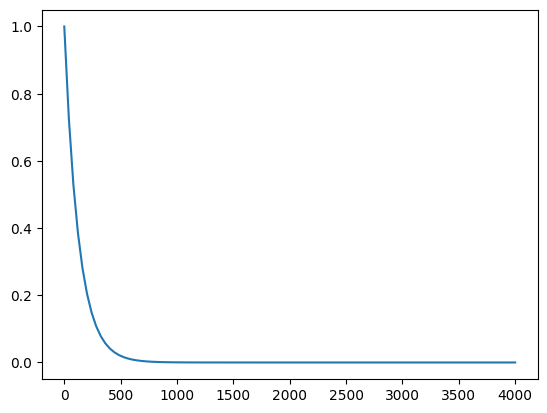

In [5]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

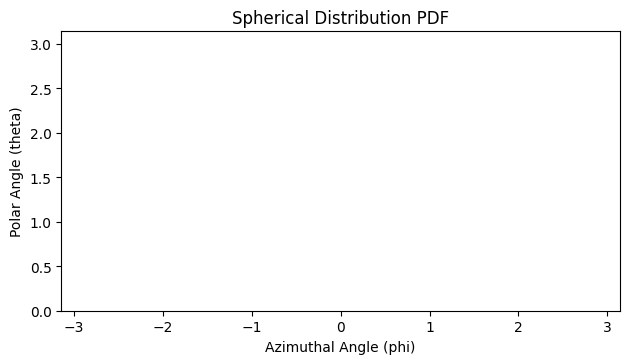

In [6]:
# Uniformly distributed signal
%matplotlib inline
ball.to_fod().viz()

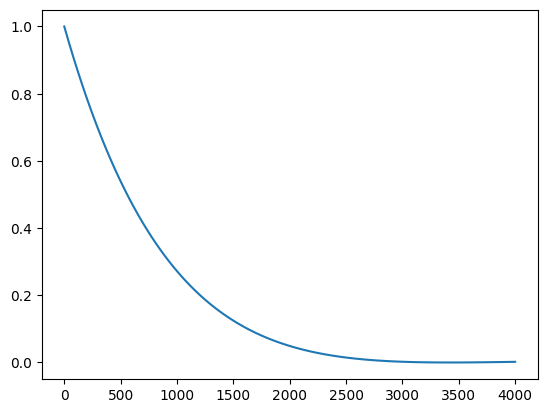

In [7]:
theta = np.random.randn(Sphere.theta_dim)
ball = Sphere.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

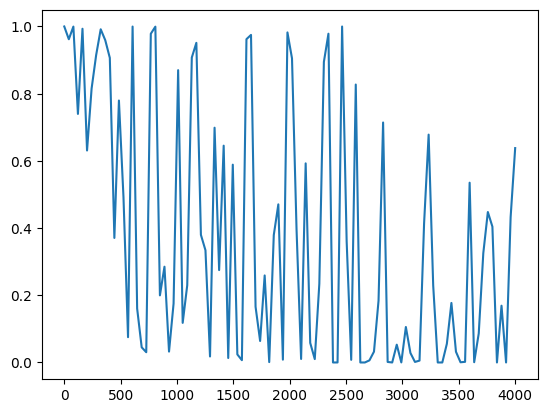

In [8]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

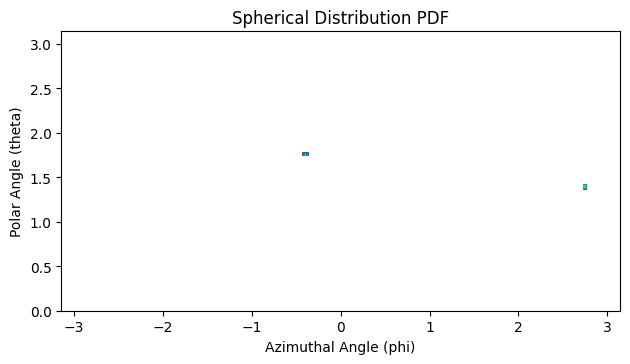

In [9]:
%matplotlib inline
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)
stick.to_fod().viz(plot_type='polar')

In [10]:
def stick_mu_samples(thetas):
    stick = Stick.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

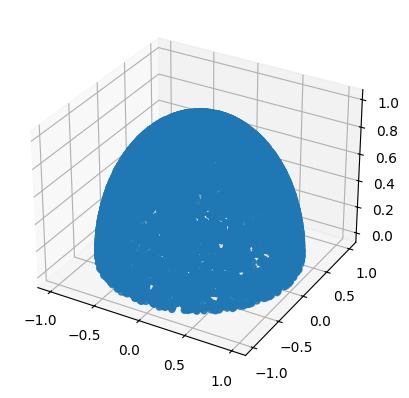

In [11]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(10000, Stick.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

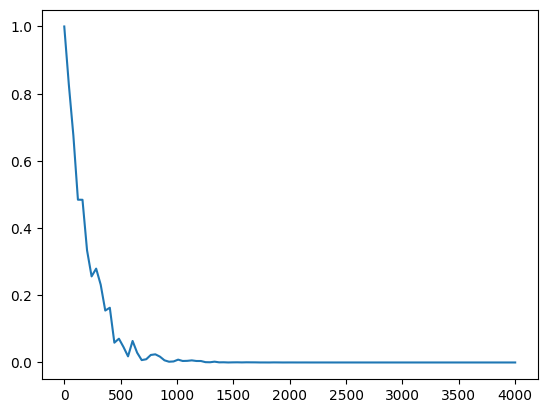

In [12]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(acq)

plt.plot(bvals, signal)

In [13]:
def stick_mu_samples(thetas):
    stick = Zeppelin.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

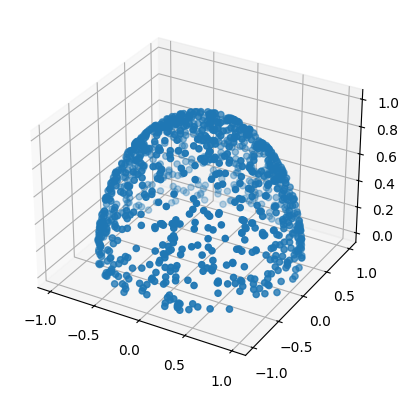

In [14]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(1000, Zeppelin.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

In [ ]:
%matplotlib inline
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)
zep.to_fod().viz()

E0704 17:34:13.894582  757117 pjrt_stream_executor_client.cc:3077] Execution of replica 0 failed: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error


XlaRuntimeError: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

: 

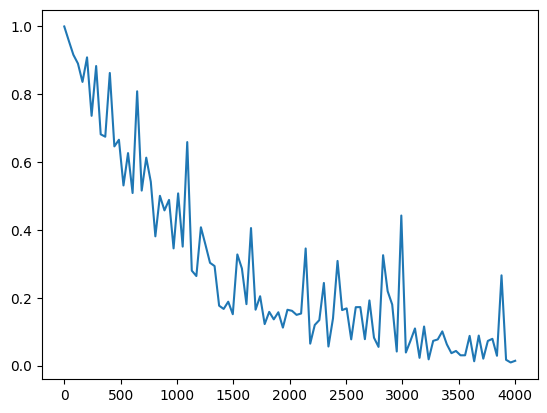

In [20]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(acq)

plt.plot(bvals, signal)

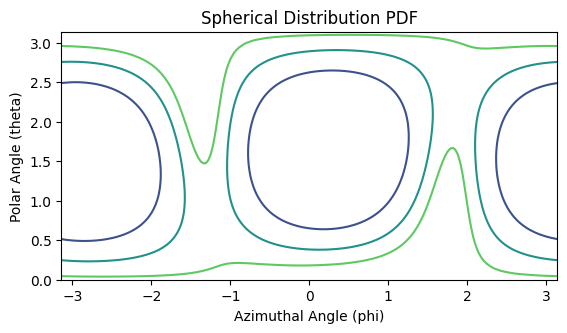

In [21]:
%matplotlib inline
dti.to_fod().viz()

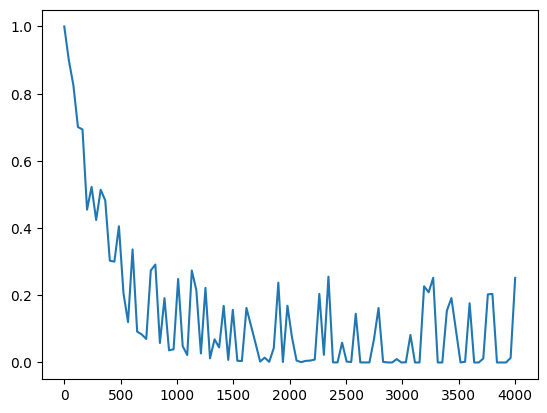

In [22]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

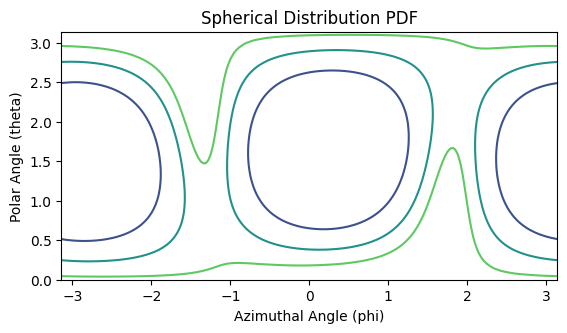

In [23]:
%matplotlib inline
dti.to_fod().viz()

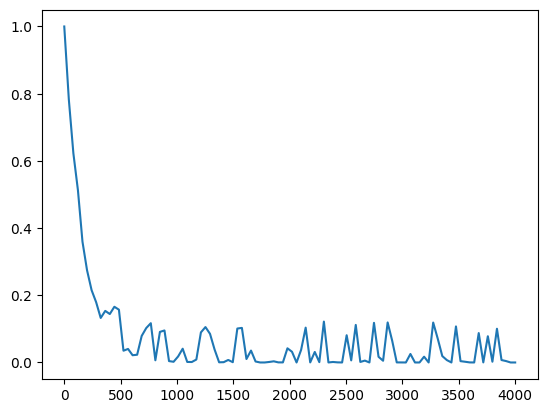

In [24]:
ball_stick_constrained = Ball3StickSharedDiffusivity.from_theta(np.random.randn(Ball3StickSharedDiffusivity.theta_dim))
signal = ball_stick_constrained.signal(acq)

plt.plot(bvals, signal)

In [25]:
ball_stick_constrained.model_compartments[1].lam_par

Array(0.00660974, dtype=float32)

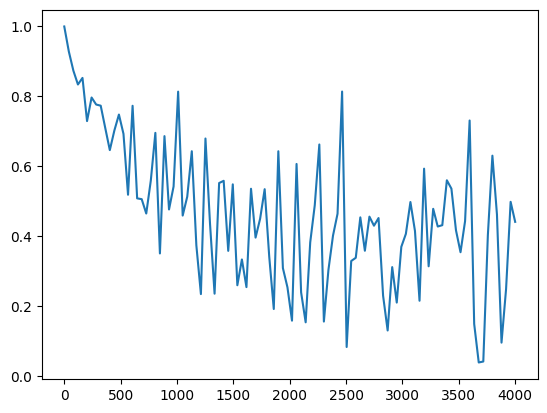

In [26]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

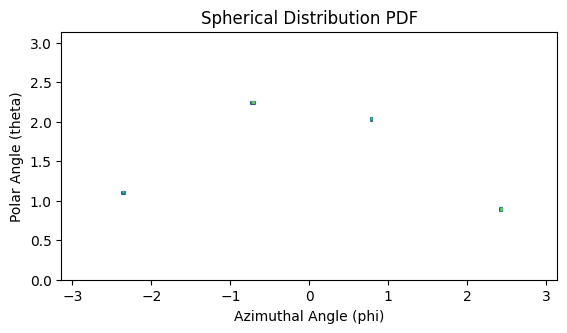

In [27]:
%matplotlib inline
ball_stick.to_fod().viz()

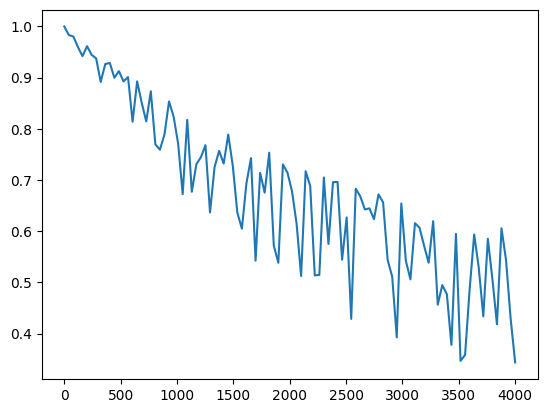

In [28]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

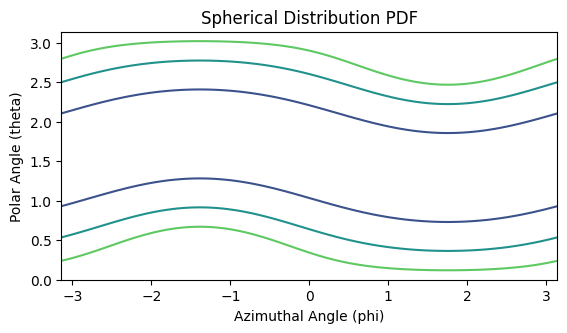

In [29]:
%matplotlib inline
racket.to_fod().viz()

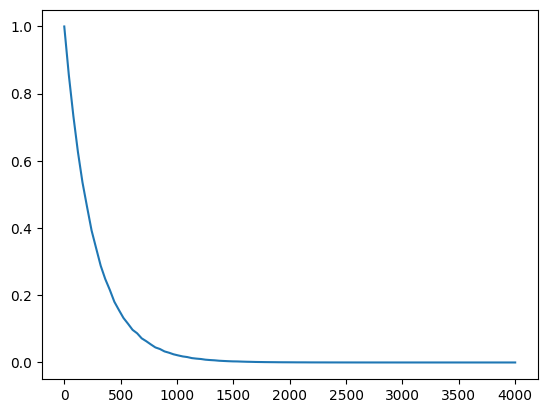

In [30]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(acq)
plt.plot(bvals, signal)

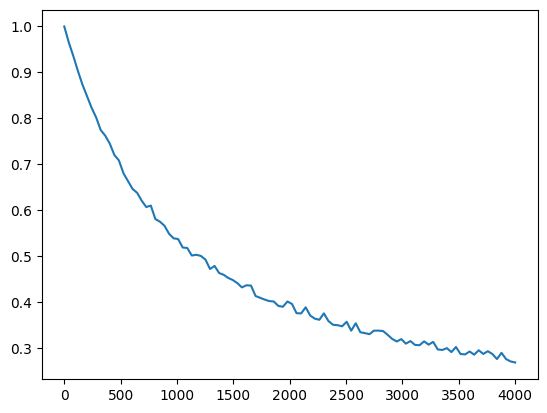

In [31]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(acq)
plt.plot(bvals, signal)

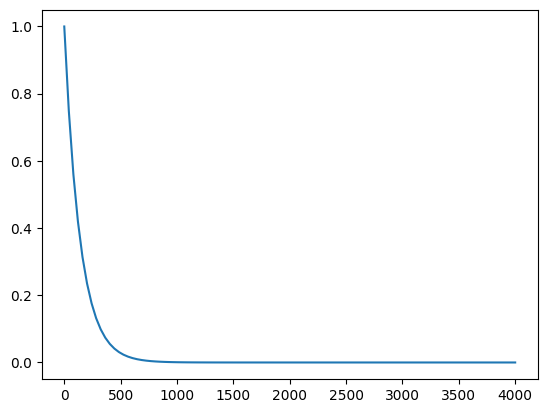

In [32]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

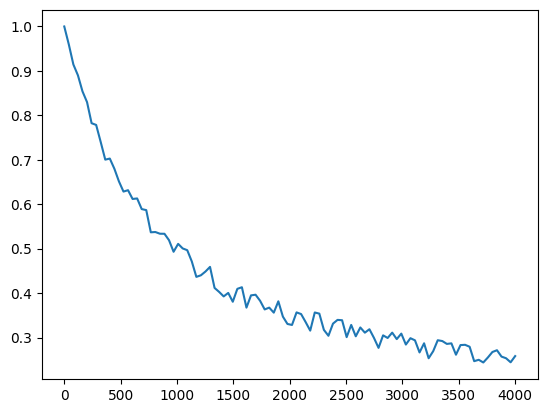

In [33]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

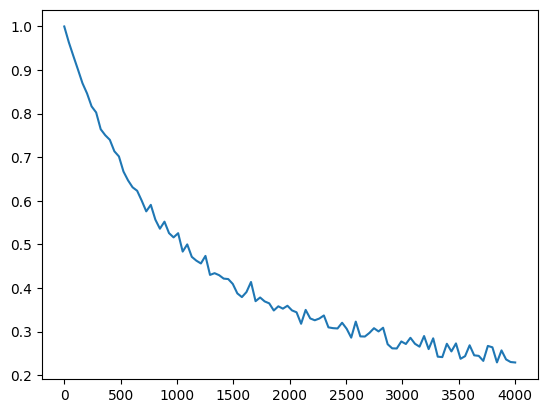

In [34]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

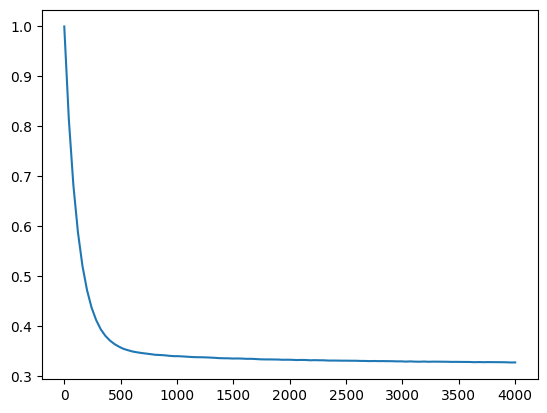

In [35]:
racket = SandiW.from_theta(np.random.randn(SandiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

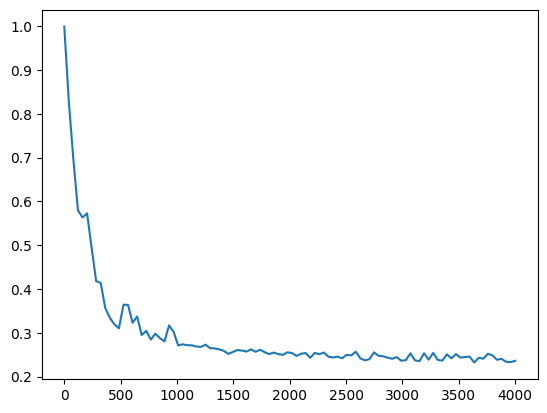

In [36]:
racket = SandiB.from_theta(np.random.randn(SandiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

# SSFP models

In [84]:
acq  = random_ssfp_acquisition(jax.random.key(0), random_prob=0.0, typical_prob=1.0)

from dmri.utils.dmriutils import ssfp_signal_fn
ssfp_signal_fn(0.00008, acq.qvals, acq.E1, acq.E2, acq.sa, acq.ca, acq.TRs, acq.diffGradDur)

Array([0.01671157, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01118077, 0.01118077, 0.01118077, 0.01118077,
       0.01118077, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01118077, 0.01118077, 0.01118077, 0.01118077,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01118077, 0.01118077, 0.01118077, 0.01118077, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01671157,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01671157, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381755,
       0.01381755, 0.01381755, 0.01381755, 0.01381755, 0.01381

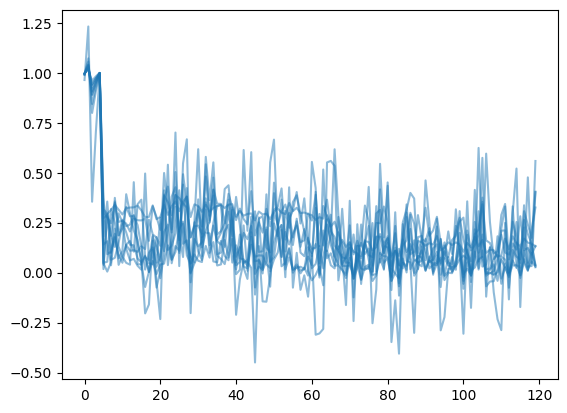

: 

In [102]:
from dmri.simulators.local_signal_models.ball import SSFPBall
from dmri.simulators.acquisition_scheme import ssfp_acquisition_scheme, random_ssfp_acquisition
from dmri.simulators.multi_compartment import SSFPBall3StickSharedDiffusivity, Ball3StickSharedDiffusivity, SSFPBall3StickSharedDiffusivityBetterNorm


acq  = random_ssfp_acquisition(jax.random.key(0), random_prob=0.0, typical_prob=1.0)


def sim(theta):
    return SSFPBall3StickSharedDiffusivityBetterNorm.from_theta(theta).signal(acq, rng=jax.random.PRNGKey(1))

signals = jax.vmap(sim)(np.random.randn(10, SSFPBall3StickSharedDiffusivityBetterNorm.theta_dim))

idx = jnp.argsort(acq.qvals)
_ = plt.plot(signals[...,idx].T, color="C0", alpha=0.5)
#plt.ylim(0, 1.1)
